# Clasificador de Frutas - ResNet18 (Transfer Learning)
## UTN - Regional Rosario

Notebook acotado: **solo ResNet18** con split **80/20** (train/test).


## Celda 0: Configuracion del entorno

In [1]:
import torch

# Detectar dispositivo: CUDA (NVIDIA/Colab) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Dispositivo: GPU NVIDIA - {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Dispositivo: Apple Silicon (MPS) - GPU Metal-accelerada')
else:
    device = torch.device('cpu')
    print('Dispositivo: CPU (no se detecto GPU)')

torch.set_num_threads(8)
print(f'Threads CPU: {torch.get_num_threads()}')


Dispositivo: GPU NVIDIA - NVIDIA GeForce RTX 3080
Memoria: 10.7 GB
Threads CPU: 8


In [2]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from utils import cargar_imagen_limpia
from dotenv import load_dotenv

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)
elif torch.backends.mps.is_available(): torch.mps.manual_seed(SEED)

print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')
print('Librerias importadas')


PyTorch 2.13.0+cu126 | Torchvision 0.28.0+cu126
Librerias importadas


---
## 1. Dataset UTN-IA 2026 - Food Classification

**Link:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set  
**Licencia:** Apache 2.0

Split **80/20** estratificado: train / test (sin validation).


### Descarga del dataset

Para descargar desde Kaggle necesitás una API key:
1. Ir a kaggle.com -> tu perfil -> Settings -> API -> Create New Token
2. Copiar `API TOKEN`
3. Pegarlo en la celda de abajo


In [3]:
load_dotenv()
token = os.environ.get('KAGGLE_API_TOKEN')
if not token:
    raise RuntimeError('Falta KAGGLE_API_TOKEN en .env (ver .env.example)')
print('Token Kaggle cargado desde .env')


Token Kaggle cargado desde .env


In [4]:
!kaggle datasets download -d geronimoforconi/utn-ia-2026-food-classification-training-set \
    -p ./data/fruit_recognition --unzip -q
print('Dataset descargado')

RAIZ_FOOD = Path('./data/fruit_recognition')


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set
License(s): apache-2.0
Dataset descargado


### Split 80/20 (train / test)

In [5]:
BASE_DIR = Path('./data/fruit_recognition_split')
CLASES   = ['apple', 'banana', 'grapes', 'potato', 'tomato']
SPLIT_TEST = 0.20

def crear_split_8020(clases, raiz, destino, split_test=0.20):
    """Split estratificado 80/20 train/test."""
    if destino.exists():
        shutil.rmtree(destino, ignore_errors=True)

    probe = raiz / clases[0]
    src_base = raiz if probe.exists() else raiz / 'train'

    for clase in clases:
        imgs = sorted([
            p for p in (src_base / clase).glob('**/*')
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png')
        ])
        if not imgs:
            print(f'Sin imagenes para clase "{clase}" en {src_base}')
            continue

        random.shuffle(imgs)
        n = len(imgs)
        n_test = int(n * split_test)

        splits = {
            'test':  imgs[:n_test],
            'train': imgs[n_test:],
        }

        for split_name, subset in splits.items():
            dst = destino / split_name / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in subset:
                shutil.copy(img, dst / img.name)

        print(f'  {clase}: {len(splits["train"])} train | {len(splits["test"])} test')

    print(f'\nSplit creado en {destino}')

crear_split_8020(CLASES, RAIZ_FOOD, BASE_DIR, SPLIT_TEST)


  apple: 43 train | 10 test
  banana: 48 train | 12 test
  grapes: 63 train | 15 test
  potato: 50 train | 12 test
  tomato: 58 train | 14 test

Split creado en data\fruit_recognition_split


---
## 2. Transforms y DataLoaders (224x224)

ResNet18 espera entradas de **224x224** con normalizacion de ImageNet.


In [6]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASES  = 5
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Pipeline base (test, sin augmentation)
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Pipeline con augmentation agresivo (train)
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 24, IMG_SIZE + 24)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_ds = ImageFolder(str(BASE_DIR / 'train'), transform=transform_train,
                        loader=cargar_imagen_limpia)
test_ds  = ImageFolder(str(BASE_DIR / 'test'),  transform=transform_base,
                        loader=cargar_imagen_limpia)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, persistent_workers=True, prefetch_factor=4, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, persistent_workers=True, prefetch_factor=4, pin_memory=False)

class_names = train_ds.classes
print(f'Loaders: train={len(train_ds)} | test={len(test_ds)}')
print(f'Clases: {class_names}')


Loaders: train=262 | test=63
Clases: ['apple', 'banana', 'grapes', 'potato', 'tomato']


---
## 3. Funciones de entrenamiento y evaluacion

In [7]:
def entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

@torch.no_grad()
def evaluar(model, loader, criterion, device):
    model.eval()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            out = model(imgs)
            loss = criterion(out, labels)
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

def graficar_historial(hist, titulo='Historial'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(hist['train_loss'], label='Train', marker='o', ms=3)
    ax1.plot(hist['test_loss'],  label='Test',  marker='s', ms=3)
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(hist['train_acc'], label='Train', marker='o', ms=3)
    ax2.plot(hist['test_acc'],  label='Test',  marker='s', ms=3)
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

@torch.no_grad()
def obtener_predicciones(model, loader, device):
    model.eval()
    preds_all, labels_all = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        _, preds = out.max(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)

def graficar_confusion(preds, labels, class_names, titulo='Confusion'):
    nombres = [c.split()[0] for c in class_names]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax1)
    ax1.set_title('Conteos'); ax1.set_xlabel('Predicho'); ax1.set_ylabel('Real')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=nombres, yticklabels=nombres, ax=ax2)
    ax2.set_title('Normalizado (recall)'); ax2.set_xlabel('Predicho'); ax2.set_ylabel('Real')
    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def graficar_reporte(preds, labels, class_names):
    print(classification_report(labels, preds, target_names=class_names))
    f1w = f1_score(labels, preds, average='weighted')
    print(f'F1 weighted: {f1w:.4f}')

def visualizar_errores(model, loader, class_names, device, n=30):
    model.eval()
    mostradas = 0
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = axes.flatten()
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    with torch.no_grad():
        for imgs_b, labels_b in loader:
            imgs_d = imgs_b.to(device)
            _, preds = model(imgs_d).max(1)
            preds = preds.cpu()
            for i in range(len(imgs_b)):
                if preds[i] != labels_b[i] and mostradas < n:
                    img = imgs_b[i] * std + mean
                    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
                    axes[mostradas].imshow(img)
                    axes[mostradas].axis('off')
                    real = class_names[labels_b[i]]
                    pred = class_names[preds[i]]
                    axes[mostradas].set_title(
                        f'Real: {real}\nPred: {pred}', fontsize=9, color='red')
                    mostradas += 1
            if mostradas >= n:
                break
    for j in range(mostradas, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'{mostradas} imagenes mal clasificadas', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Funciones definidas')


Funciones definidas


---
## 4. Modelo ResNet18 (Transfer Learning)

Cargamos ResNet18 pre-entrenada en ImageNet y reemplazamos la capa final.


In [8]:
Path('./checkpoints').mkdir(parents=True, exist_ok=True)

modelo = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Reemplazar la fc final por una con NUM_CLASES salidas
num_features = modelo.fc.in_features   # 512 en resnet18
modelo.fc = nn.Linear(num_features, NUM_CLASES)

# Freeze del backbone (solo entrena fc en etapa 1)
for param in modelo.parameters():
    param.requires_grad = False
for param in modelo.fc.parameters():
    param.requires_grad = True

modelo = modelo.to(device)

trainable = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
total     = sum(p.numel() for p in modelo.parameters())
print(f'ResNet18 cargado en {device}')
print(f'  Parametros entrenables: {trainable:,} / {total:,}')


ResNet18 cargado en cuda
  Parametros entrenables: 2,565 / 11,179,077


---
## 5. Etapa 1 - Entrenar solo la cabeza (FC nueva)

Backbone congelado, solo entrena la capa `fc` nueva.


In [9]:
EPOCHS_HEAD = 10
LR_HEAD    = 1e-3

optimizer_head = optim.Adam([p for p in modelo.parameters() if p.requires_grad],
                            lr=LR_HEAD, weight_decay=1e-4)
scheduler_head = optim.lr_scheduler.CosineAnnealingLR(optimizer_head, T_max=EPOCHS_HEAD)

criterion = nn.CrossEntropyLoss()

historial_head = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
mejor_head = float('inf')
CKPT_HEAD = './checkpoints/resnet18_head.pth'

print('=== Etapa 1: entrenando solo la cabeza (fc nueva) ===')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Test Loss":>10} | {"Test Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS_HEAD + 1):
    tl, ta = entrenar_epoch(modelo, train_loader, criterion, optimizer_head, device)
    vl, va = evaluar(modelo, test_loader, criterion, device)
    scheduler_head.step()
    for k, v in [('train_loss',tl),('test_loss',vl),('train_acc',ta),('test_acc',va)]:
        historial_head[k].append(v)
    marca = ''
    if vl < mejor_head:
        mejor_head = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo.state_dict(),
                    'test_acc':va, 'stage':'head'}, CKPT_HEAD)
        marca = ' **'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')

print(f'\nEtapa 1 completa. Mejor test_acc: {max(historial_head["test_acc"]):.2%}')


=== Etapa 1: entrenando solo la cabeza (fc nueva) ===
 Epoch | Train Loss |  Train Acc |  Test Loss |   Test Acc
----------------------------------------------------------
     1 |     1.5147 |     38.2% |     1.3003 |     49.2% **
     2 |     1.1324 |     59.9% |     0.9750 |     68.3% **
     3 |     0.8708 |     74.8% |     0.7856 |     74.6% **
     4 |     0.7270 |     81.3% |     0.7045 |     81.0% **
     5 |     0.6542 |     85.5% |     0.6196 |     84.1% **
     6 |     0.6023 |     88.2% |     0.5536 |     88.9% **
     7 |     0.5780 |     88.2% |     0.5173 |     87.3% **
     8 |     0.5477 |     88.5% |     0.5200 |     88.9%
     9 |     0.5083 |     91.2% |     0.5167 |     88.9% **
    10 |     0.4827 |     91.6% |     0.5131 |     88.9% **

Etapa 1 completa. Mejor test_acc: 88.89%


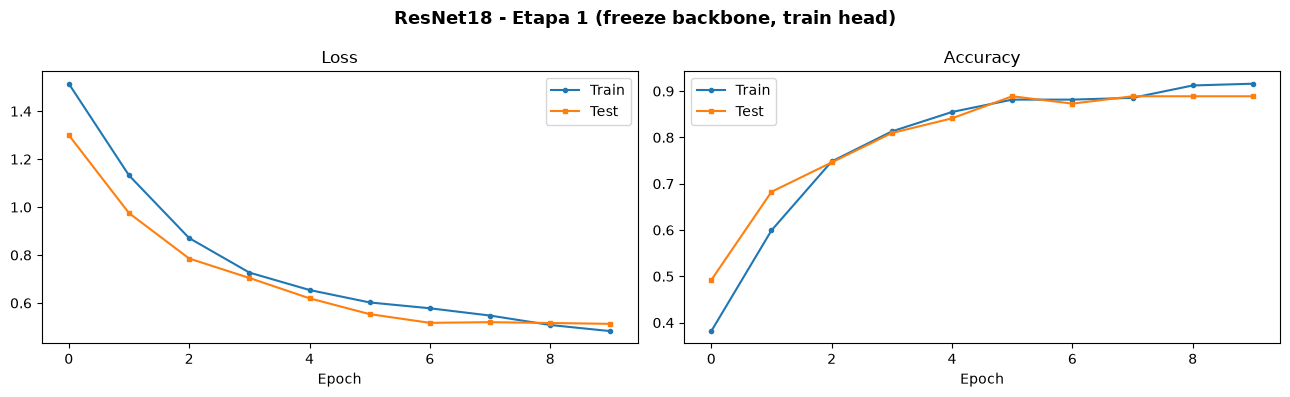

In [10]:
graficar_historial(historial_head, titulo='ResNet18 - Etapa 1 (freeze backbone, train head)')


---
## 6. Etapa 2 - Fine-tuning completo (unfreeze)

Descongelamos todo el backbone y entrenamos con un LR mucho mas bajo.


In [11]:
# === Etapa 2: UNFREEZE de TODO el modelo ===
for param in modelo.parameters():
    param.requires_grad = True

# Cargar el mejor checkpoint de la etapa 1 para arrancar desde ahi
ckpt_head = torch.load(CKPT_HEAD, map_location=device)
modelo.load_state_dict(ckpt_head['model_state_dict'])
print(f'Resumiendo desde etapa 1 (epoch {ckpt_head["epoch"]}, test_acc {ckpt_head["test_acc"]:.2%})')

EPOCHS_FT   = 100
LR_FT       = 1e-5

optimizer_ft = optim.Adam(modelo.parameters(), lr=LR_FT, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_FT)

historial_ft = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
mejor_ft = float('inf')
CKPT_FT = './checkpoints/resnet18_ft.pth'

print(f'\n=== Etapa 2: fine-tuning completo (unfreeze, LR={LR_FT}) ===')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Test Loss":>10} | {"Test Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS_FT + 1):
    tl, ta = entrenar_epoch(modelo, train_loader, criterion, optimizer_ft, device)
    vl, va = evaluar(modelo, test_loader, criterion, device)
    scheduler_ft.step()
    for k, v in [('train_loss',tl),('test_loss',vl),('train_acc',ta),('test_acc',va)]:
        historial_ft[k].append(v)
    marca = ''
    if vl < mejor_ft:
        mejor_ft = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo.state_dict(),
                    'test_acc':va, 'stage':'finetune'}, CKPT_FT)
        marca = ' **'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')

print(f'\nEtapa 2 completa. Mejor test_acc: {max(historial_ft["test_acc"]):.2%}')


Resumiendo desde etapa 1 (epoch 10, test_acc 88.89%)

=== Etapa 2: fine-tuning completo (unfreeze, LR=1e-05) ===
 Epoch | Train Loss |  Train Acc |  Test Loss |   Test Acc
----------------------------------------------------------
     1 |     0.4725 |     89.7% |     0.4635 |     88.9% **
     2 |     0.4326 |     89.7% |     0.4409 |     88.9% **
     3 |     0.3720 |     92.0% |     0.3968 |     90.5% **
     4 |     0.3334 |     92.4% |     0.3846 |     92.1% **
     5 |     0.2948 |     93.5% |     0.3460 |     93.7% **
     6 |     0.2550 |     95.0% |     0.3271 |     92.1% **
     7 |     0.2441 |     93.9% |     0.3121 |     92.1% **
     8 |     0.2182 |     97.3% |     0.3189 |     92.1%
     9 |     0.2139 |     95.8% |     0.3005 |     92.1% **
    10 |     0.1937 |     96.2% |     0.2978 |     92.1% **
    11 |     0.1791 |     95.8% |     0.2832 |     92.1% **
    12 |     0.1897 |     96.2% |     0.2692 |     93.7% **
    13 |     0.1440 |     98.1% |     0.2783 |     9

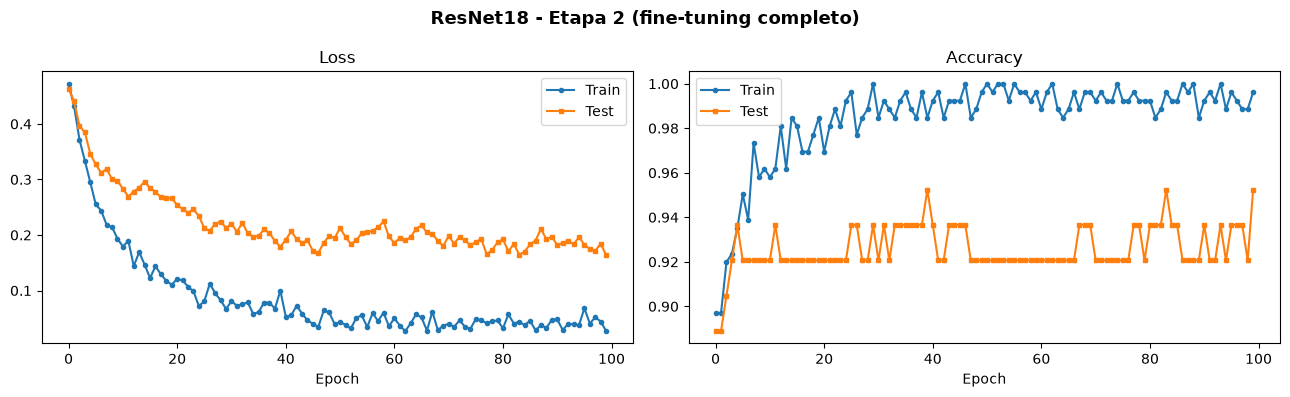

In [12]:
graficar_historial(historial_ft, titulo='ResNet18 - Etapa 2 (fine-tuning completo)')


---
## 7. Evaluacion final: matriz de confusion + errores

Cargamos el mejor checkpoint del fine-tuning y evaluamos sobre el set de test.


Modelo cargado: epoch 100 | test_acc 95.24%


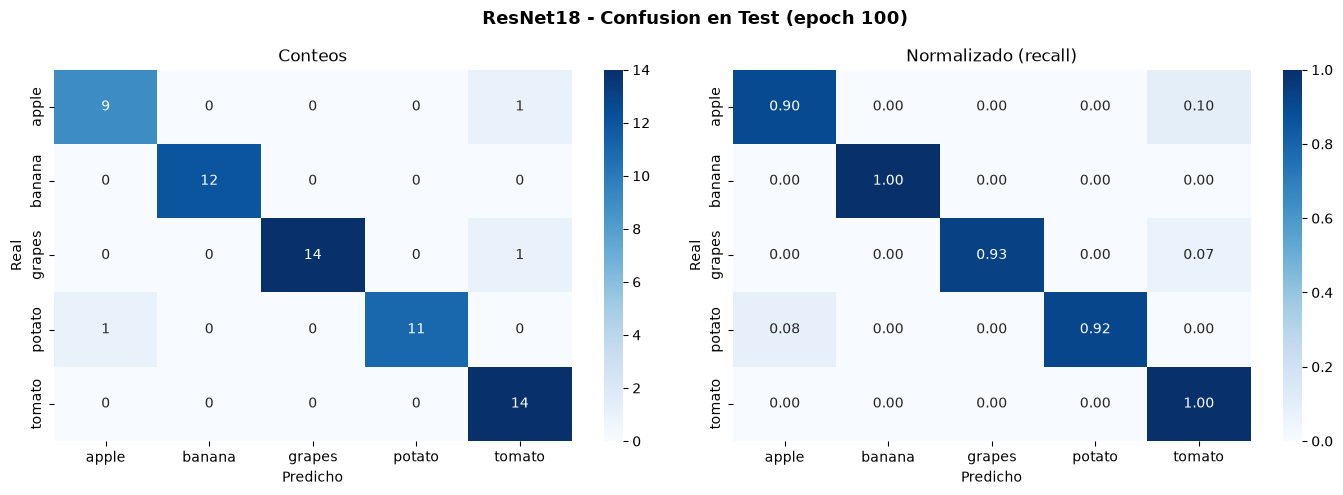

              precision    recall  f1-score   support

       apple       0.90      0.90      0.90        10
      banana       1.00      1.00      1.00        12
      grapes       1.00      0.93      0.97        15
      potato       1.00      0.92      0.96        12
      tomato       0.88      1.00      0.93        14

    accuracy                           0.95        63
   macro avg       0.96      0.95      0.95        63
weighted avg       0.96      0.95      0.95        63

F1 weighted: 0.9528

--- 30 errores de clasificacion (test) ---


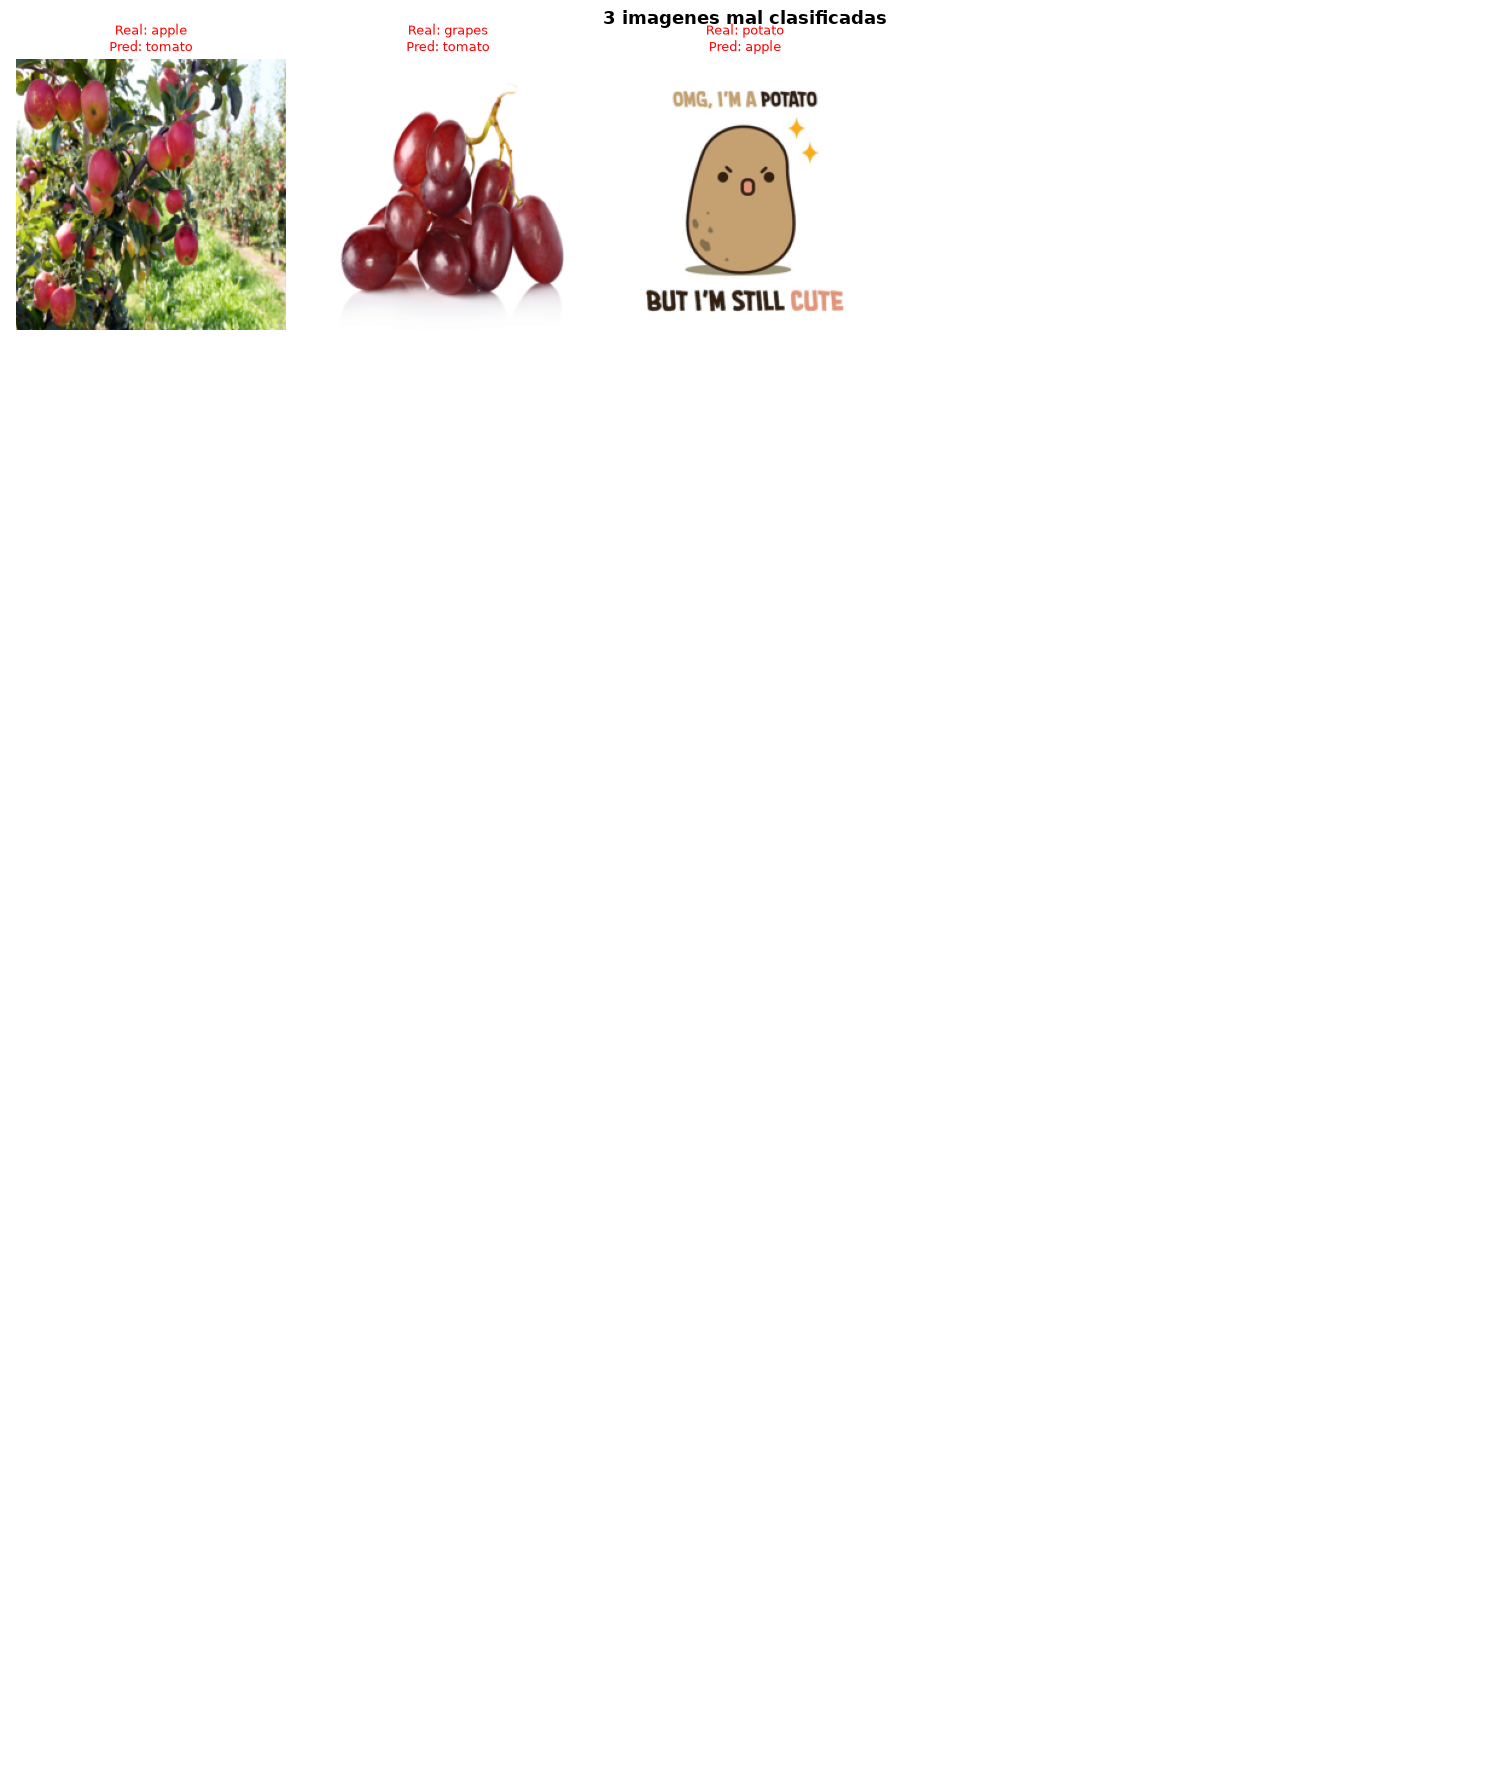

In [13]:
# === Matriz de confusion + 30 errores en test ===
ckpt_final = torch.load(CKPT_FT, map_location=device)
modelo.load_state_dict(ckpt_final['model_state_dict'])
print(f'Modelo cargado: epoch {ckpt_final["epoch"]} | test_acc {ckpt_final["test_acc"]:.2%}')

preds_t, labels_t = obtener_predicciones(modelo, test_loader, device)
graficar_confusion(preds_t, labels_t, class_names,
                   titulo=f'ResNet18 - Confusion en Test (epoch {ckpt_final["epoch"]})')
graficar_reporte(preds_t, labels_t, class_names)

print('\n--- 30 errores de clasificacion (test) ---')
visualizar_errores(modelo, test_loader, class_names, device, n=30)


In [14]:
import zipfile
COMP_DIR = Path('./data/test_competencia')
COMP_DIR.mkdir(parents=True, exist_ok=True)

test_images_dir = COMP_DIR / 'test_images'
if not test_images_dir.exists():
    !kaggle competitions download \
        -c utn-ia-2026-fruit-vegetable-classifier \
        -p {COMP_DIR}

    zip_files = list(COMP_DIR.glob('*.zip'))
    for zf in zip_files:
        print(f'Descomprimiendo {zf.name}...')
        with zipfile.ZipFile(zf, 'r') as z:
            z.extractall(COMP_DIR)
        zf.unlink()
    print('Dataset de test descargado y descomprimido')
else:
    print(f'Dataset de test ya presente en {test_images_dir}')


Descomprimiendo utn-ia-2026-fruit-vegetable-classifier.zip...
Dataset de test descargado y descomprimido



  0%|          | 0.00/38.9M [00:00<?, ?B/s]
  3%|2         | 1.00M/38.9M [00:00<00:34, 1.15MB/s]
  5%|5         | 2.00M/38.9M [00:01<00:16, 2.33MB/s]
 10%|#         | 4.00M/38.9M [00:01<00:07, 5.04MB/s]
 18%|#7        | 7.00M/38.9M [00:01<00:03, 9.55MB/s]
 28%|##8       | 11.0M/38.9M [00:01<00:01, 15.1MB/s]
 36%|###5      | 14.0M/38.9M [00:01<00:01, 18.5MB/s]
 44%|####3     | 17.0M/38.9M [00:01<00:01, 21.5MB/s]
 51%|#####1    | 20.0M/38.9M [00:01<00:00, 23.5MB/s]
 59%|#####9    | 23.0M/38.9M [00:01<00:00, 18.3MB/s]
 67%|######6   | 26.0M/38.9M [00:02<00:00, 20.4MB/s]
 77%|#######7  | 30.0M/38.9M [00:02<00:00, 23.8MB/s]
 87%|########7 | 34.0M/38.9M [00:02<00:00, 26.1MB/s]
 95%|#########5| 37.0M/38.9M [00:02<00:00, 26.5MB/s]
100%|##########| 38.9M/38.9M [00:02<00:00, 16.1MB/s]


In [15]:
candidate_dirs = [
    COMP_DIR / 'test_images',
    COMP_DIR / 'utn-ia-2026-fruit-vegetable-classifier' / 'test_images',
]
for d in candidate_dirs:
    if d.exists():
        test_images_dir = d
        break
else:
    for p in COMP_DIR.rglob('*'):
        if p.is_dir() and (any(p.glob('*.jpg')) or any(p.glob('*.png'))):
            test_images_dir = p
            break

imagenes_test = sorted([
    p for p in test_images_dir.rglob('*')
    if p.suffix.lower() in ['.jpg', '.jpeg', '.png']
])
print(f'{len(imagenes_test)} imagenes de test encontradas en {test_images_dir}')
print('Primeras 5:', [p.name for p in imagenes_test[:5]])

89 imagenes de test encontradas en data\test_competencia\utn_competencia_test\test_images
Primeras 5: ['img_00000.jpg', 'img_00001.jpg', 'img_00002.jpg', 'img_00003.jpg', 'img_00004.jpg']


In [16]:
ckpt_final = torch.load(CKPT_FT, map_location=device)
modelo.load_state_dict(ckpt_final['model_state_dict'])
modelo.eval()
print(f'Modelo cargado: epoch {ckpt_final["epoch"]} | test_acc {ckpt_final["test_acc"]:.2%}')

CLASES_MODELO = class_names
CLASES_COMP = ['apple', 'banana', 'grapes', 'potato', 'tomato']

@torch.no_grad()
def predecir_imagen(modelo, img_path, device, use_tta=True):
    img = cargar_imagen_limpia(img_path)
    predicciones = []

    base_t = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

    if use_tta:
        transforms_tta = [
            base_t,
            transforms.Compose([transforms.RandomHorizontalFlip(p=1.0),
                                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=MEAN, std=STD)]),
            transforms.Compose([transforms.RandomVerticalFlip(p=1.0),
                                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=MEAN, std=STD)]),
        ]
    else:
        transforms_tta = [base_t]

    for t in transforms_tta:
        tensor = t(img).unsqueeze(0).to(device)
        with torch.autocast(device_type=device.type if device.type in ('mps','cuda') else 'cpu'):
            logits = modelo(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        predicciones.append(probs)

    probs_promedio = np.mean(predicciones, axis=0)
    pred_idx = int(np.argmax(probs_promedio))
    pred_label = CLASES_MODELO[pred_idx]
    return pred_label, probs_promedio

if imagenes_test:
    label, probs = predecir_imagen(modelo, imagenes_test[0], device, use_tta=True)
    print(f'Primer imagen: {imagenes_test[0].name} -> {label}')
    print(f'Probs: {dict(zip(CLASES_MODELO, np.round(probs, 3)))}')

Modelo cargado: epoch 100 | test_acc 95.24%
Primer imagen: img_00000.jpg -> grapes
Probs: {'apple': np.float16(0.001), 'banana': np.float16(0.001), 'grapes': np.float16(0.997), 'potato': np.float16(0.001), 'tomato': np.float16(0.0)}


In [17]:
import pandas as pd
from datetime import datetime

submissions_dir = Path('./submissions')
submissions_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
submission_path = submissions_dir / f'submission_resnet18_{timestamp}.csv'

predicciones = []
print(f'Prediciendo {len(imagenes_test)} imagenes con TTA...')
for i, img_path in enumerate(imagenes_test):
    pred_label, _ = predecir_imagen(modelo, img_path, device, use_tta=True)
    pred_label = pred_label.lower().strip()
    if pred_label not in CLASES_COMP:
        pred_label = pred_label.split()[0].lower()
    image_id = img_path.stem
    predicciones.append({'image_id': image_id, 'label': pred_label})
    if (i + 1) % 50 == 0 or (i + 1) == len(imagenes_test):
        print(f'  {i+1}/{len(imagenes_test)} procesadas')

df_sub = pd.DataFrame(predicciones)

clases_invalidas = df_sub[~df_sub['label'].isin(CLASES_COMP)]
if len(clases_invalidas) > 0:
    print(f'{len(clases_invalidas)} predicciones con clases invalidas:')
    print(clases_invalidas)
else:
    print(f'Todas las {len(df_sub)} predicciones tienen clases validas')

df_sub.to_csv(submission_path, index=False)
print(f'\nSubmission guardado en: {submission_path}')
print(f'Tamano: {len(df_sub)} filas')

print(f'\nDistribucion de predicciones:')
print(df_sub['label'].value_counts().sort_index())
print(f'\nPrimeras 10 filas:')
print(df_sub.head(10))

Prediciendo 89 imagenes con TTA...
  50/89 procesadas
  89/89 procesadas
Todas las 89 predicciones tienen clases validas

Submission guardado en: submissions\submission_resnet18_20260727_220643.csv
Tamano: 89 filas

Distribucion de predicciones:
label
apple     16
banana    17
grapes    21
potato    14
tomato    21
Name: count, dtype: int64

Primeras 10 filas:
    image_id   label
0  img_00000  grapes
1  img_00001  grapes
2  img_00002   apple
3  img_00003  banana
4  img_00004  tomato
5  img_00005  grapes
6  img_00006  potato
7  img_00007  potato
8  img_00008  grapes
9  img_00009  potato


In [18]:
print('=== Validacion del submission ===')
print(f'1. Columnas: {list(df_sub.columns)} (esperado: [image_id, label])')
print(f'2. Filas: {len(df_sub)}')
print(f'3. Nulos: {df_sub.isnull().sum().sum()}')
print(f'4. Clases unicas: {sorted(df_sub["label"].unique())}')
print(f'5. Clases esperadas: {CLASES_COMP}')
matches = set(df_sub['label'].unique()) == set(CLASES_COMP)
print(f'6. Match exacto: {"SI" if matches else "NO"}')

df_sub.to_csv(submission_path, index=False)

print(f'\n=== Primeras 5 lineas del archivo {submission_path.name} ===')
with open(submission_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(line.rstrip())

=== Validacion del submission ===
1. Columnas: ['image_id', 'label'] (esperado: [image_id, label])
2. Filas: 89
3. Nulos: 0
4. Clases unicas: ['apple', 'banana', 'grapes', 'potato', 'tomato']
5. Clases esperadas: ['apple', 'banana', 'grapes', 'potato', 'tomato']
6. Match exacto: SI

=== Primeras 5 lineas del archivo submission_resnet18_20260727_220643.csv ===
image_id,label
img_00000,grapes
img_00001,grapes
img_00002,apple
img_00003,banana
